# Traffic Sign Classification — Part II: Vision Tasks
**Student Name:** Numa Subba  
**University ID:** 2407656  
**Module:** 6CS012 — Artificial Intelligence and Machine Learning  



In [1]:
from google.colab import files
uploaded = files.upload()

Saving Traffic_Sign-20260416T070512Z-3-001.zip to Traffic_Sign-20260416T070512Z-3-001.zip


In [2]:
import zipfile
import os

zip_path = "Traffic_Sign-20260416T070512Z-3-001.zip"
extract_path = "dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction done!")

Extraction done!


In [3]:
import os

for root, dirs, files in os.walk("dataset"):
    print("Folder:", root)
    print("Subfolders:", dirs)
    print("Files:", len(files))
    print("-"*30)

Folder: dataset
Subfolders: ['Traffic_Sign']
Files: 0
------------------------------
Folder: dataset/Traffic_Sign
Subfolders: ['Train', 'Test']
Files: 1
------------------------------
Folder: dataset/Traffic_Sign/Train
Subfolders: ['Instructions', 'OverSpeed', 'No Passing', 'Caution']
Files: 0
------------------------------
Folder: dataset/Traffic_Sign/Train/Instructions
Subfolders: []
Files: 2848
------------------------------
Folder: dataset/Traffic_Sign/Train/OverSpeed
Subfolders: []
Files: 5249
------------------------------
Folder: dataset/Traffic_Sign/Train/No Passing
Subfolders: []
Files: 5369
------------------------------
Folder: dataset/Traffic_Sign/Train/Caution
Subfolders: []
Files: 2429
------------------------------
Folder: dataset/Traffic_Sign/Test
Subfolders: []
Files: 4
------------------------------


In [4]:
import os

for root, dirs, files in os.walk("dataset"):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            print(os.path.join(root, file))
            break

dataset/Traffic_Sign/Train/Instructions/00034_00003_00013.png
dataset/Traffic_Sign/Train/OverSpeed/00005_00041_00012.png
dataset/Traffic_Sign/Train/No Passing/00010_00058_00025.png
dataset/Traffic_Sign/Train/Caution/00023_00004_00020.png
dataset/Traffic_Sign/Test/00018_00000_00001.png


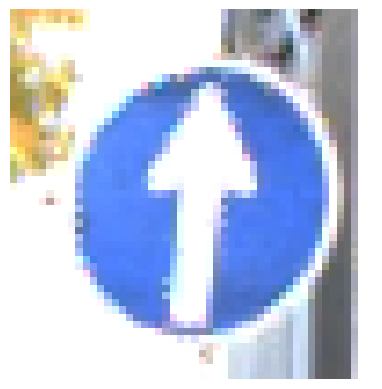

In [5]:
import matplotlib.pyplot as plt
import cv2

sample_path = "dataset/Traffic_Sign/Train/Instructions/00035_00017_00015.png"

img = cv2.imread(sample_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis("off")
plt.show()

In [6]:
train_path = "dataset/Traffic_Sign/Train"
test_path = "dataset/Traffic_Sign/Test"

In [7]:
import os
import pandas as pd

classes = sorted(os.listdir(train_path))

data = []
total_images = 0

for cls in classes:
    cls_path = os.path.join(train_path, cls)
    count = len([f for f in os.listdir(cls_path) if f.lower().endswith((".jpg", ".jpeg", ".png"))])
    data.append([cls, count])
    total_images += count

df = pd.DataFrame(data, columns=["Class", "Number of Images"])

print("Total classes:", len(classes))
print("Total training images:", total_images)
df

Total classes: 4
Total training images: 15895


,Class,Number of Images
0,Caution,2429
1,Instructions,2848
2,No Passing,5369
3,OverSpeed,5249


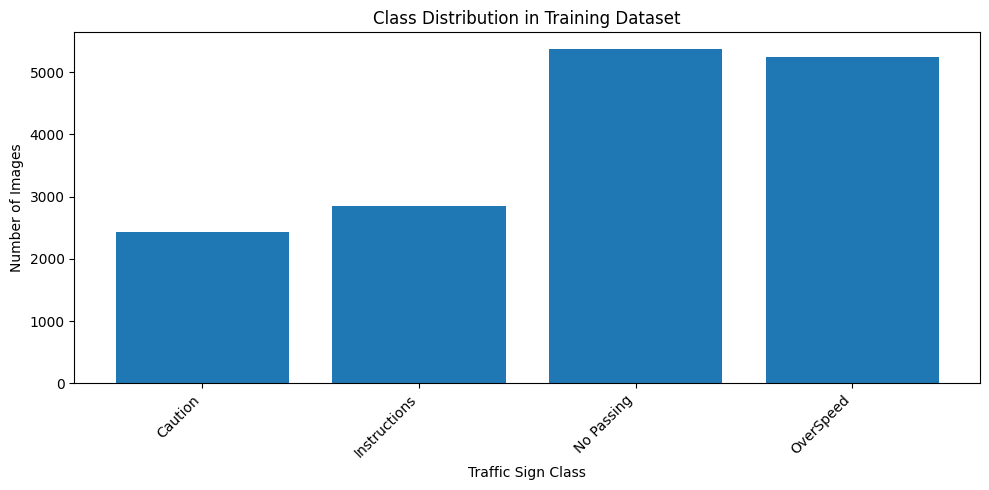

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.bar(df["Class"], df["Number of Images"])
plt.xticks(rotation=45, ha="right")
plt.title("Class Distribution in Training Dataset")
plt.xlabel("Traffic Sign Class")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.show()

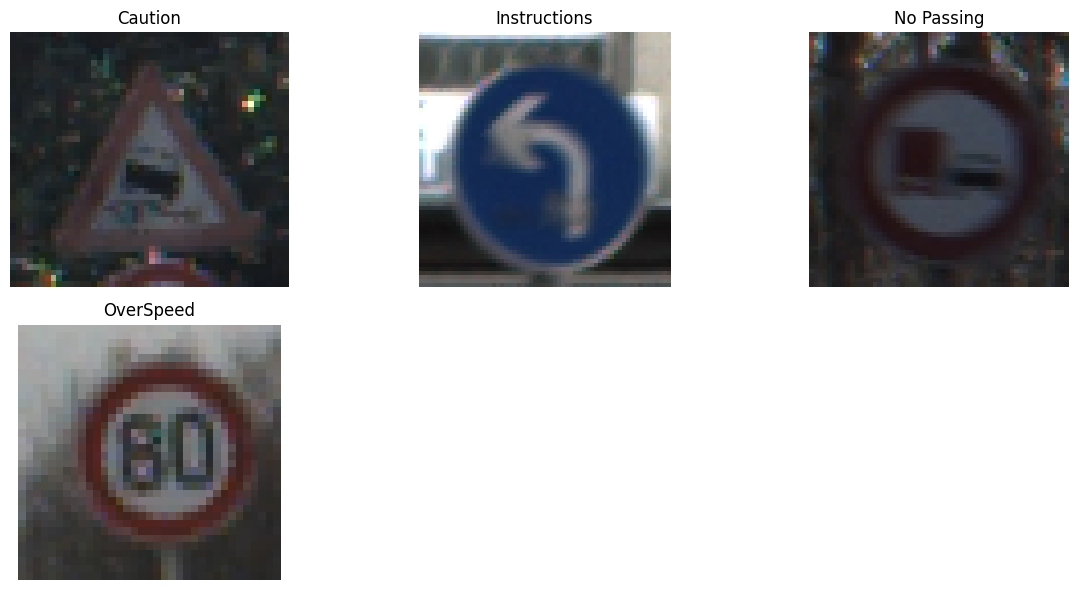

In [9]:
import matplotlib.pyplot as plt
import cv2
import os

plt.figure(figsize=(12, 6))

for i, cls in enumerate(classes):
    cls_path = os.path.join(train_path, cls)
    img_name = os.listdir(cls_path)[0]
    img_path = os.path.join(cls_path, img_name)

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 3, i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [10]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 64
BATCH_SIZE = 32

train_path = "dataset/Traffic_Sign/Train"
test_path = "dataset/Traffic_Sign/Test"

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    train_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True
)

val_data = datagen.flow_from_directory(
    train_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)

print("Classes:", train_data.class_indices)

Found 12719 images belonging to 4 classes.
Found 3176 images belonging to 4 classes.
Classes: {'Caution': 0, 'Instructions': 1, 'No Passing': 2, 'OverSpeed': 3}


In [11]:
from tensorflow.keras import layers, models

baseline_model = models.Sequential([
    layers.Input(shape=(64, 64, 3)),

    layers.Conv2D(32, (3,3), activation="relu"),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation="relu"),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation="relu"),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),

    layers.Dense(4, activation="softmax")
])

baseline_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 693,668 (2.65 MB)

 Trainable params: 693,668 (2.65 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
from PIL import Image
import os

bad_files = []

for folder in [train_path, test_path]:
    for root, dirs, files in os.walk(folder):
        for file in files:
            if file.lower().endswith((".jpg", ".jpeg", ".png")):
                path = os.path.join(root, file)
                try:
                    img = Image.open(path)
                    img.verify()
                except:
                    bad_files.append(path)

print("Bad files found:", len(bad_files))
for f in bad_files[:20]:
    print(f)

Bad files found: 28
dataset/Traffic_Sign/Train/Instructions/00035_00003_00001.png
dataset/Traffic_Sign/Train/Instructions/00035_00019_00013.png
dataset/Traffic_Sign/Train/Instructions/00028_00007_00009.png
dataset/Traffic_Sign/Train/Instructions/00033_00015_00004.png
dataset/Traffic_Sign/Train/Instructions/00028_00017_00025.png
dataset/Traffic_Sign/Train/Instructions/00028_00013_00012.png
dataset/Traffic_Sign/Train/Instructions/00028_00001_00009.png
dataset/Traffic_Sign/Train/OverSpeed/00004_00058_00025.png
dataset/Traffic_Sign/Train/OverSpeed/00005_00043_00008.png
dataset/Traffic_Sign/Train/OverSpeed/00004_00005_00020.png
dataset/Traffic_Sign/Train/OverSpeed/00005_00009_00027.png
dataset/Traffic_Sign/Train/OverSpeed/00005_00035_00027.png
dataset/Traffic_Sign/Train/OverSpeed/00005_00058_00027.png
dataset/Traffic_Sign/Train/OverSpeed/00004_00057_00006.png
dataset/Traffic_Sign/Train/No Passing/00009_00000_00023.png
dataset/Traffic_Sign/Train/No Passing/00010_00019_00022.png
dataset/Traff

In [13]:
for f in bad_files:
    os.remove(f)

print("Bad files deleted:", len(bad_files))

Bad files deleted: 28


In [14]:
train_data = datagen.flow_from_directory(
    train_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True
)

val_data = datagen.flow_from_directory(
    train_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)

Found 12695 images belonging to 4 classes.
Found 3172 images belonging to 4 classes.


In [15]:
history_baseline = baseline_model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 21s 31ms/step - accuracy: 0.9358 - loss: 0.1672 - val_accuracy: 0.7954 - val_loss: 3.8904
Epoch 2/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.9957 - loss: 0.0148 - val_accuracy: 0.8143 - val_loss: 3.5427
Epoch 3/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.9985 - loss: 0.0050 - val_accuracy: 0.8127 - val_loss: 4.1995
Epoch 4/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.9961 - loss: 0.0137 - val_accuracy: 0.8181 - val_loss: 3.2012
Epoch 5/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.9965 - loss: 0.0125 - val_accuracy: 0.8247 - val_loss: 3.6235
Epoch 6/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.9989 - loss: 0.0042 - val_accuracy: 0.8219 - val_loss: 4.3262
Epoch 7/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.9985 - loss: 0.0054 - val_accuracy: 0.8172 - val_loss: 4.0350
Epoch 8/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.9991 - loss: 0.0031 - val_acc

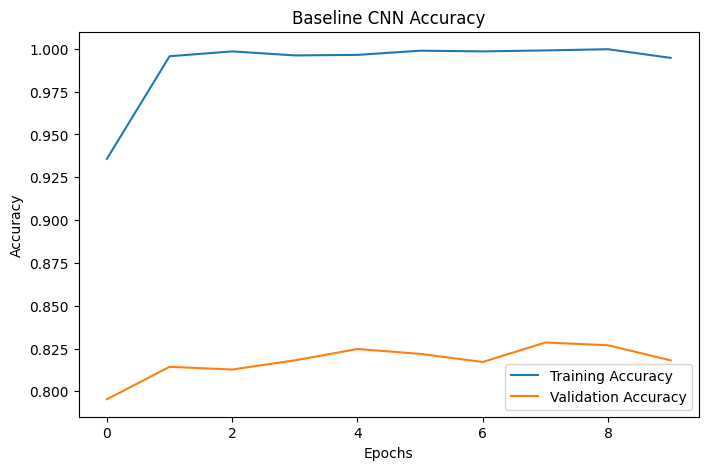

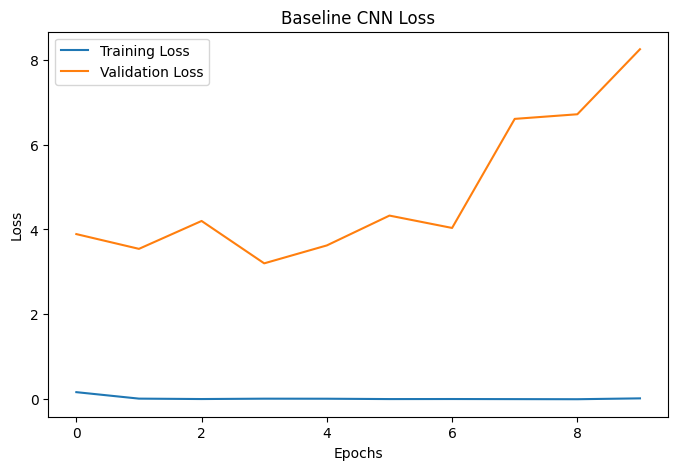

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history_baseline.history["accuracy"], label="Training Accuracy")
plt.plot(history_baseline.history["val_accuracy"], label="Validation Accuracy")
plt.title("Baseline CNN Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(history_baseline.history["loss"], label="Training Loss")
plt.plot(history_baseline.history["val_loss"], label="Validation Loss")
plt.title("Baseline CNN Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [17]:
baseline_loss, baseline_acc = baseline_model.evaluate(val_data)

print("Baseline Validation Accuracy:", baseline_acc)
print("Baseline Validation Loss:", baseline_loss)

100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.8181 - loss: 8.2450 
Baseline Validation Accuracy: 0.818095862865448
Baseline Validation Loss: 8.244974136352539


100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step
=== Baseline CNN Classification Report ===
              precision    recall  f1-score   support

     Caution       0.47      1.00      0.64       484
Instructions       0.91      0.05      0.10       568
  No Passing       1.00      0.97      0.98      1072
   OverSpeed       0.97      0.99      0.98      1048

    accuracy                           0.82      3172
   macro avg       0.84      0.75      0.68      3172
weighted avg       0.89      0.82      0.77      3172



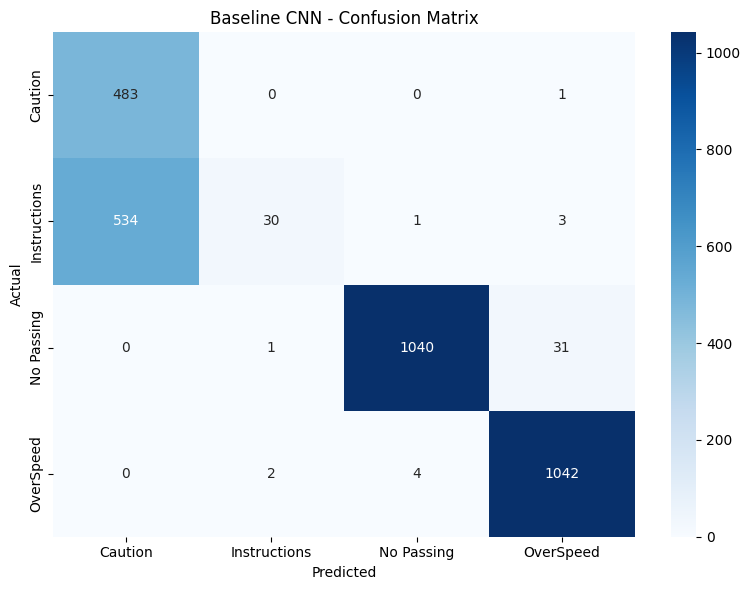

In [18]:
# Confusion Matrix + Classification Report - Baseline CNN
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np

val_data.reset()
y_pred_baseline = baseline_model.predict(val_data)
y_pred_classes = np.argmax(y_pred_baseline, axis=1)
y_true = val_data.classes

class_names = list(val_data.class_indices.keys())

print("=== Baseline CNN Classification Report ===")
print(classification_report(y_true, y_pred_classes, target_names=class_names))

cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.title("Baseline CNN - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 718ms/step


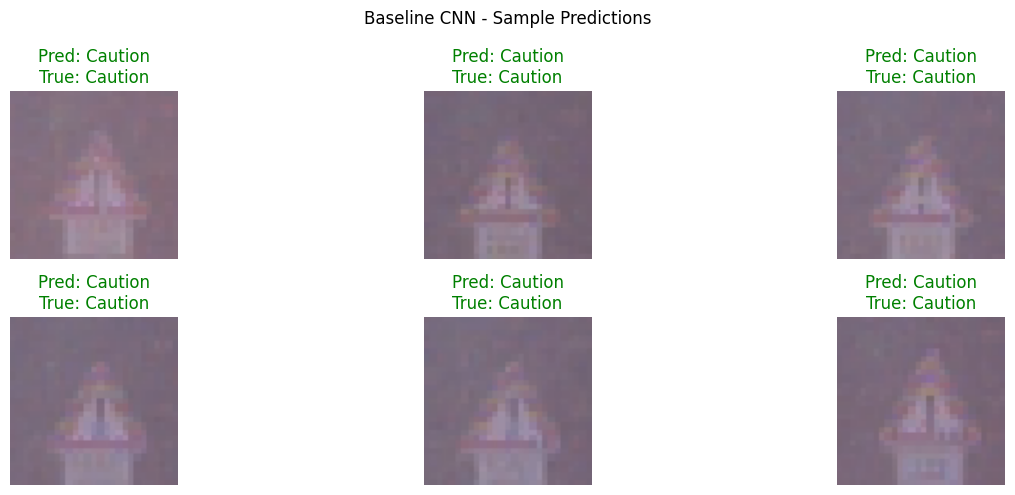

In [19]:
# ── Sample Inference with Predicted Labels: Baseline CNN ──
val_data.reset()
images_batch, labels_batch = next(val_data)

preds = baseline_model.predict(images_batch[:6])

plt.figure(figsize=(14, 5))
for i in range(6):
    pred_label = class_names[np.argmax(preds[i])]
    true_label = class_names[np.argmax(labels_batch[i])]
    plt.subplot(2, 3, i+1)
    plt.imshow(images_batch[i])
    color = 'green' if pred_label == true_label else 'red'
    plt.title(f'Pred: {pred_label}\nTrue: {true_label}', color=color)
    plt.axis('off')
plt.suptitle('Baseline CNN - Sample Predictions')
plt.tight_layout()
plt.show()

In [20]:
from tensorflow.keras import layers, models

deeper_model = models.Sequential([
    layers.Input(shape=(64, 64, 3)),

    layers.Conv2D(32, (3,3), activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(256, (3,3), activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),

    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(64, activation="relu"),

    layers.Dense(4, activation="softmax")
])

deeper_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

deeper_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 62, 62, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 29, 29, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 4, 4, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 694,148 (2.65 MB)

 Trainable params: 693,188 (2.64 MB)

 Non-trainable params: 960 (3.75 KB)

In [21]:
history_deeper = deeper_model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 24s 37ms/step - accuracy: 0.9326 - loss: 0.1841 - val_accuracy: 0.6072 - val_loss: 1.5350
Epoch 2/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.9928 - loss: 0.0230 - val_accuracy: 0.7869 - val_loss: 4.7079
Epoch 3/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.9954 - loss: 0.0153 - val_accuracy: 0.7409 - val_loss: 2.4089
Epoch 4/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.9963 - loss: 0.0141 - val_accuracy: 0.7932 - val_loss: 8.0338
Epoch 5/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.9987 - loss: 0.0053 - val_accuracy: 0.8266 - val_loss: 9.8211
Epoch 6/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.9967 - loss: 0.0114 - val_accuracy: 0.7658 - val_loss: 8.8245
Epoch 7/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.9961 - loss: 0.0190 - val_accuracy: 0.8159 - val_loss: 15.0638
Epoch 8/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.9994 - loss: 0.0029 - val_ac

In [22]:
deeper_loss, deeper_acc = deeper_model.evaluate(val_data)

print("Deeper CNN Validation Accuracy:", deeper_acc)
print("Deeper CNN Validation Loss:", deeper_loss)

100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.7970 - loss: 4.0836
Deeper CNN Validation Accuracy: 0.7969735264778137
Deeper CNN Validation Loss: 4.083620548248291


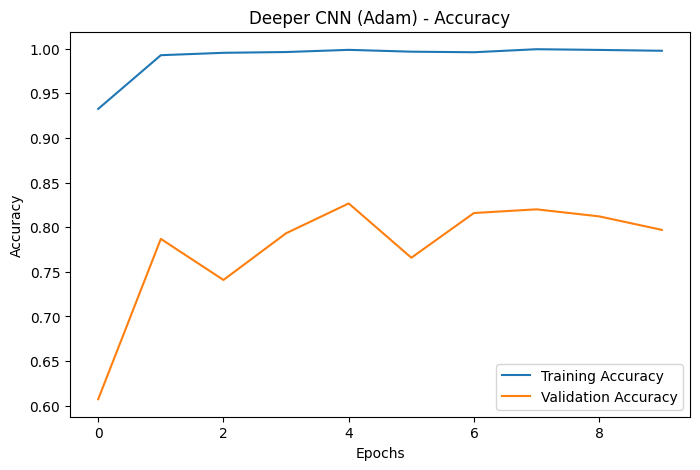

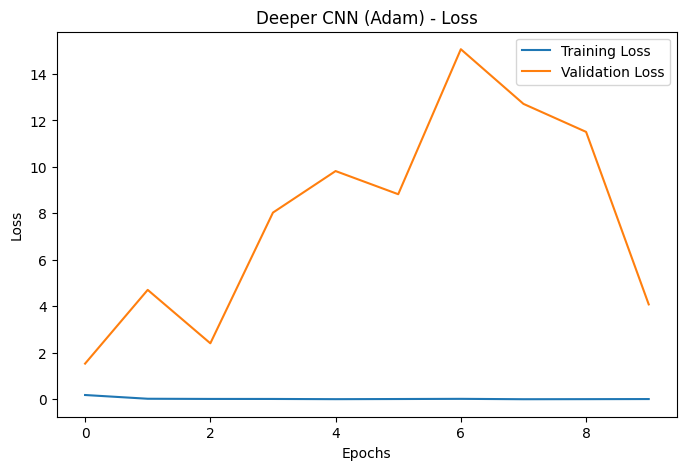

100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step
=== Deeper CNN (Adam) Classification Report ===
              precision    recall  f1-score   support

     Caution       0.48      0.96      0.64       484
Instructions       0.70      0.06      0.11       568
  No Passing       0.92      0.98      0.95      1072
   OverSpeed       0.98      0.93      0.95      1048

    accuracy                           0.80      3172
   macro avg       0.77      0.73      0.66      3172
weighted avg       0.83      0.80      0.75      3172



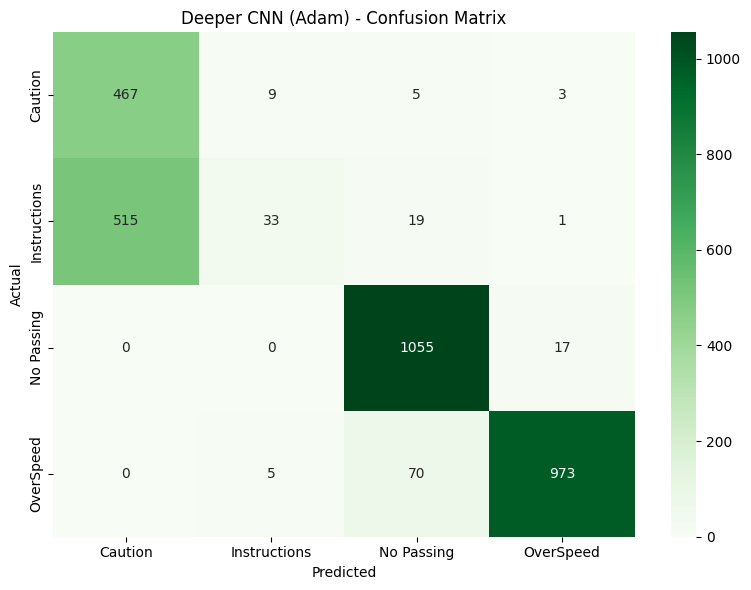

In [23]:
# ── Accuracy/Loss Plots + Confusion Matrix: Deeper CNN (Adam) ──
plt.figure(figsize=(8,5))
plt.plot(history_deeper.history['accuracy'], label='Training Accuracy')
plt.plot(history_deeper.history['val_accuracy'], label='Validation Accuracy')
plt.title('Deeper CNN (Adam) - Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(history_deeper.history['loss'], label='Training Loss')
plt.plot(history_deeper.history['val_loss'], label='Validation Loss')
plt.title('Deeper CNN (Adam) - Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

val_data.reset()
y_pred_deeper = deeper_model.predict(val_data)
y_pred_deeper_classes = np.argmax(y_pred_deeper, axis=1)
y_true = val_data.classes

print('=== Deeper CNN (Adam) Classification Report ===')
print(classification_report(y_true, y_pred_deeper_classes, target_names=class_names))

cm_deeper = confusion_matrix(y_true, y_pred_deeper_classes)
plt.figure(figsize=(8,6))
sns.heatmap(cm_deeper, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Deeper CNN (Adam) - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [24]:
deeper_sgd_model = tf.keras.models.clone_model(deeper_model)

deeper_sgd_model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_sgd = deeper_sgd_model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

sgd_loss, sgd_acc = deeper_sgd_model.evaluate(val_data)

print("SGD Validation Accuracy:", sgd_acc)
print("SGD Validation Loss:", sgd_loss)

Epoch 1/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 18s 33ms/step - accuracy: 0.6887 - loss: 0.8322 - val_accuracy: 0.5779 - val_loss: 1.1383
Epoch 2/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.9019 - loss: 0.2862 - val_accuracy: 0.6400 - val_loss: 1.6353
Epoch 3/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.9514 - loss: 0.1539 - val_accuracy: 0.7610 - val_loss: 1.7120
Epoch 4/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.9699 - loss: 0.0948 - val_accuracy: 0.7547 - val_loss: 1.8314
Epoch 5/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.9783 - loss: 0.0715 - val_accuracy: 0.7673 - val_loss: 1.9609
Epoch 6/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.9824 - loss: 0.0544 - val_accuracy: 0.7957 - val_loss: 2.1886
Epoch 7/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.9882 - loss: 0.0401 - val_accuracy: 0.7755 - val_loss: 2.1357
Epoch 8/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.9911 - loss: 0.0337 - val_acc

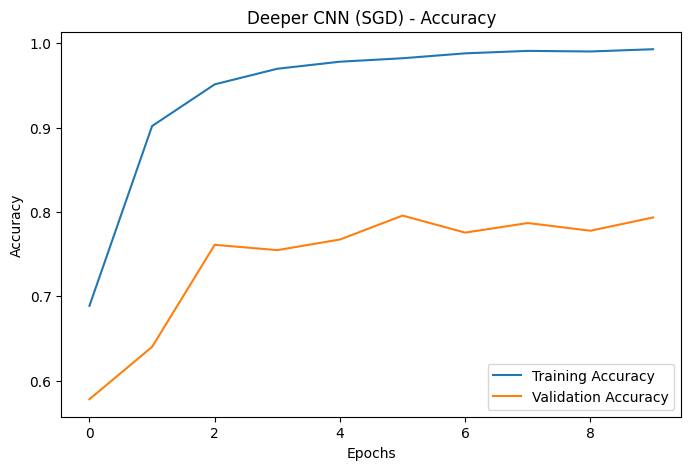

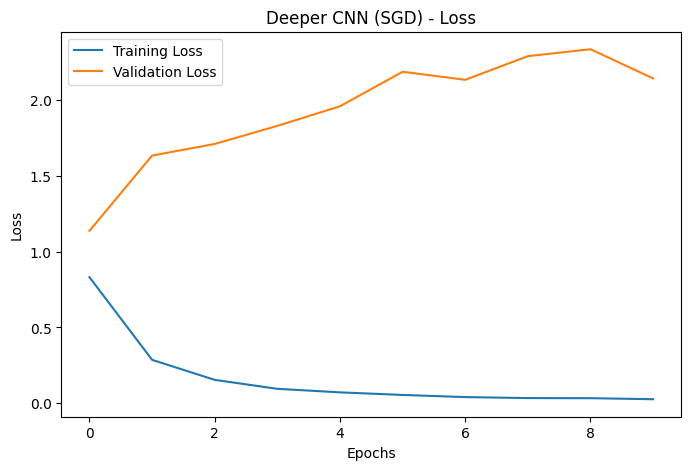

100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step
=== Deeper CNN (SGD) Classification Report ===
              precision    recall  f1-score   support

     Caution       0.44      0.87      0.59       484
Instructions       0.97      0.06      0.11       568
  No Passing       0.97      0.96      0.97      1072
   OverSpeed       0.91      0.99      0.95      1048

    accuracy                           0.79      3172
   macro avg       0.82      0.72      0.65      3172
weighted avg       0.87      0.79      0.75      3172



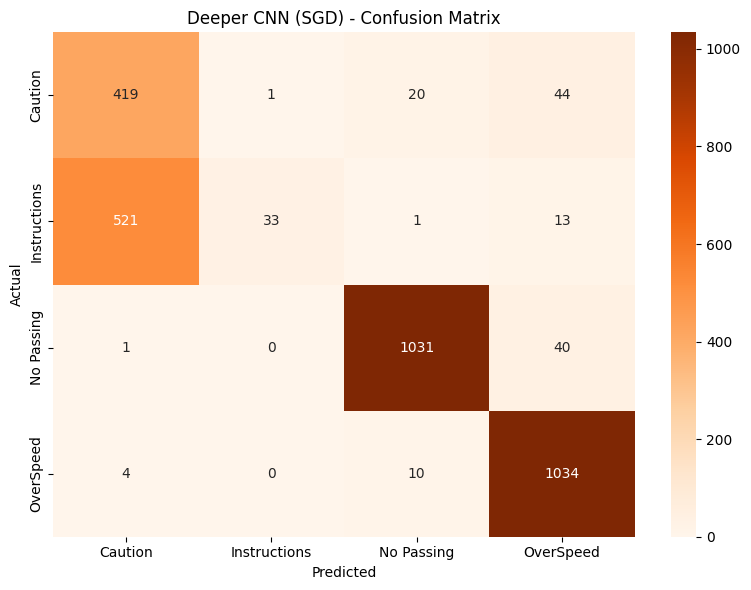

In [25]:
# ── Accuracy/Loss Plots + Confusion Matrix: Deeper CNN (SGD) ──
plt.figure(figsize=(8,5))
plt.plot(history_sgd.history['accuracy'], label='Training Accuracy')
plt.plot(history_sgd.history['val_accuracy'], label='Validation Accuracy')
plt.title('Deeper CNN (SGD) - Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(history_sgd.history['loss'], label='Training Loss')
plt.plot(history_sgd.history['val_loss'], label='Validation Loss')
plt.title('Deeper CNN (SGD) - Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

val_data.reset()
y_pred_sgd = deeper_sgd_model.predict(val_data)
y_pred_sgd_classes = np.argmax(y_pred_sgd, axis=1)
y_true = val_data.classes

print('=== Deeper CNN (SGD) Classification Report ===')
print(classification_report(y_true, y_pred_sgd_classes, target_names=class_names))

cm_sgd = confusion_matrix(y_true, y_pred_sgd_classes)
plt.figure(figsize=(8,6))
sns.heatmap(cm_sgd, annot=True, fmt='d', cmap='Oranges',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Deeper CNN (SGD) - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [26]:
# ── Ablation Study: Remove Dropout from Deeper Model ──
import time

ablation_model = models.Sequential([
    layers.Input(shape=(64, 64, 3)),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(256, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),

    layers.Dense(256, activation='relu'),
    # Dropout REMOVED for ablation study

    layers.Dense(128, activation='relu'),
    # Dropout REMOVED for ablation study

    layers.Dense(64, activation='relu'),
    layers.Dense(4, activation='softmax')
])

ablation_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print('Training Ablation Model (No Dropout)...')
start_time = time.time()
history_ablation = ablation_model.fit(train_data, validation_data=val_data, epochs=10)
end_time = time.time()

ablation_loss, ablation_acc = ablation_model.evaluate(val_data)
print(f'\nAblation Model (No Dropout) - Validation Accuracy: {ablation_acc:.4f}')
print(f'Ablation Model (No Dropout) - Validation Loss:     {ablation_loss:.4f}')
print(f'Total Training Time: {(end_time - start_time):.2f} seconds')

print(f'\nDeeper CNN with Dropout    - Accuracy: {deeper_acc:.4f} | Loss: {deeper_loss:.4f}')
print(f'Ablation Model no Dropout  - Accuracy: {ablation_acc:.4f} | Loss: {ablation_loss:.4f}')

Training Ablation Model (No Dropout)...
Epoch 1/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 19s 33ms/step - accuracy: 0.9709 - loss: 0.0767 - val_accuracy: 0.7661 - val_loss: 1.4443
Epoch 2/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.9980 - loss: 0.0069 - val_accuracy: 0.8086 - val_loss: 5.0864
Epoch 3/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.9959 - loss: 0.0149 - val_accuracy: 0.7705 - val_loss: 5.2628
Epoch 4/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.9978 - loss: 0.0070 - val_accuracy: 0.8168 - val_loss: 4.7552
Epoch 5/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.9992 - loss: 0.0031 - val_accuracy: 0.7954 - val_loss: 3.4977
Epoch 6/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.9967 - loss: 0.0120 - val_accuracy: 0.7850 - val_loss: 4.7868
Epoch 7/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.9986 - loss: 0.0050 - val_accuracy: 0.7976 - val_loss: 8.1024
Epoch 8/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - 

In [27]:
IMG_SIZE_TL = 224
BATCH_SIZE = 32

tl_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data_tl = tl_datagen.flow_from_directory(
    train_path,
    target_size=(IMG_SIZE_TL, IMG_SIZE_TL),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True
)

val_data_tl = tl_datagen.flow_from_directory(
    train_path,
    target_size=(IMG_SIZE_TL, IMG_SIZE_TL),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)

Found 12695 images belonging to 4 classes.
Found 3172 images belonging to 4 classes.


In [28]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

transfer_model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(4, activation="softmax")
])

transfer_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

transfer_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [29]:
history_transfer = transfer_model.fit(
    train_data_tl,
    validation_data=val_data_tl,
    epochs=5
)

Epoch 1/5
397/397 ━━━━━━━━━━━━━━━━━━━━ 66s 118ms/step - accuracy: 0.9334 - loss: 0.1761 - val_accuracy: 0.7762 - val_loss: 2.5683
Epoch 2/5
397/397 ━━━━━━━━━━━━━━━━━━━━ 44s 56ms/step - accuracy: 0.9771 - loss: 0.0638 - val_accuracy: 0.7919 - val_loss: 3.0196
Epoch 3/5
397/397 ━━━━━━━━━━━━━━━━━━━━ 19s 47ms/step - accuracy: 0.9818 - loss: 0.0479 - val_accuracy: 0.7938 - val_loss: 3.8151
Epoch 4/5
397/397 ━━━━━━━━━━━━━━━━━━━━ 19s 49ms/step - accuracy: 0.9897 - loss: 0.0312 - val_accuracy: 0.7941 - val_loss: 4.2073
Epoch 5/5
397/397 ━━━━━━━━━━━━━━━━━━━━ 20s 50ms/step - accuracy: 0.9900 - loss: 0.0273 - val_accuracy: 0.7885 - val_loss: 3.6206


In [30]:
transfer_loss, transfer_acc = transfer_model.evaluate(val_data_tl)

print("Transfer Learning Validation Accuracy:", transfer_acc)
print("Transfer Learning Validation Loss:", transfer_loss)

100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - accuracy: 0.7885 - loss: 3.6206
Transfer Learning Validation Accuracy: 0.7884615659713745
Transfer Learning Validation Loss: 3.6205661296844482


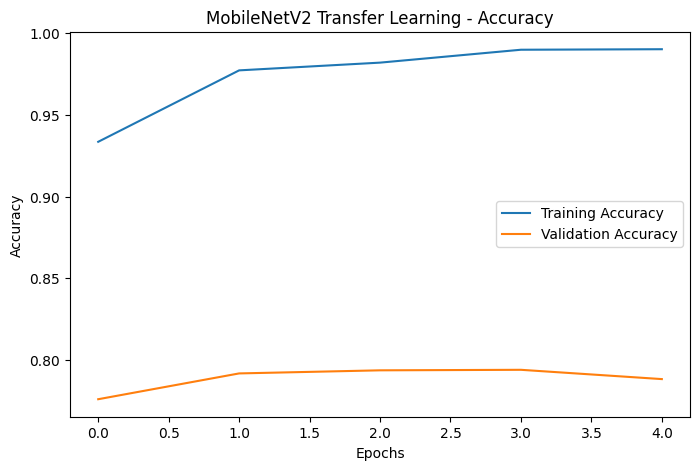

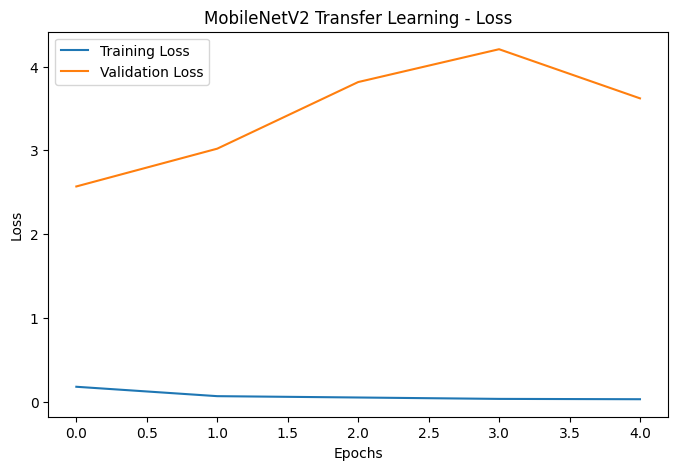

100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 89ms/step
=== MobileNetV2 Classification Report ===
              precision    recall  f1-score   support

     Caution       0.47      0.98      0.64       484
Instructions       0.67      0.06      0.10       568
  No Passing       0.96      0.93      0.94      1072
   OverSpeed       0.92      0.96      0.94      1048

    accuracy                           0.79      3172
   macro avg       0.75      0.73      0.66      3172
weighted avg       0.82      0.79      0.74      3172



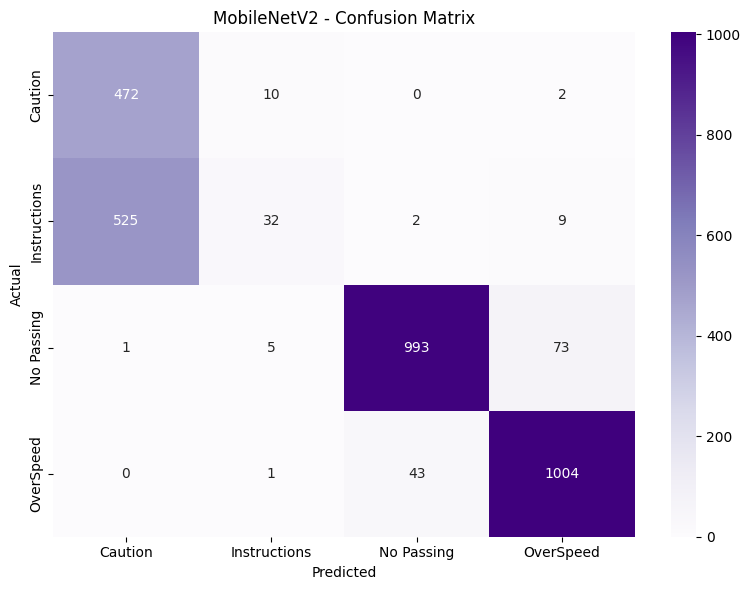

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


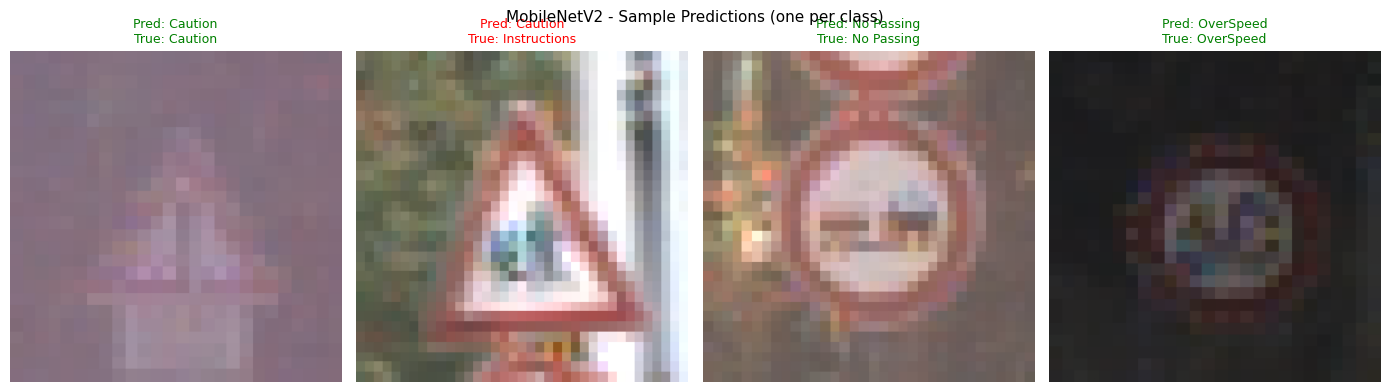

In [31]:
# ── Accuracy/Loss Plots + Confusion Matrix + Inference: MobileNetV2 ──
plt.figure(figsize=(8,5))
plt.plot(history_transfer.history['accuracy'], label='Training Accuracy')
plt.plot(history_transfer.history['val_accuracy'], label='Validation Accuracy')
plt.title('MobileNetV2 Transfer Learning - Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(history_transfer.history['loss'], label='Training Loss')
plt.plot(history_transfer.history['val_loss'], label='Validation Loss')
plt.title('MobileNetV2 Transfer Learning - Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

val_data_tl.reset()
y_pred_tl = transfer_model.predict(val_data_tl)
y_pred_tl_classes = np.argmax(y_pred_tl, axis=1)
y_true_tl = val_data_tl.classes
class_names_tl = list(val_data_tl.class_indices.keys())

print('=== MobileNetV2 Classification Report ===')
print(classification_report(y_true_tl, y_pred_tl_classes, target_names=class_names_tl))

cm_tl = confusion_matrix(y_true_tl, y_pred_tl_classes)
plt.figure(figsize=(8,6))
sns.heatmap(cm_tl, annot=True, fmt='d', cmap='Purples',
            xticklabels=class_names_tl, yticklabels=class_names_tl)
plt.title('MobileNetV2 - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# ── Sample Inference: one image from EACH of the 4 classes ──
val_data_tl.reset()
collected = {}  # class_index -> (image, label)

for images_batch, labels_batch in val_data_tl:
    for i in range(len(images_batch)):
        cls_idx = np.argmax(labels_batch[i])
        if cls_idx not in collected:
            collected[cls_idx] = (images_batch[i], labels_batch[i])
    if len(collected) == len(class_names_tl):
        break

sorted_items = sorted(collected.items())
sample_images = np.array([item[1][0] for item in sorted_items])
sample_labels = np.array([item[1][1] for item in sorted_items])
preds_tl = transfer_model.predict(sample_images)

plt.figure(figsize=(14, 4))
for i in range(len(class_names_tl)):
    pred_label = class_names_tl[np.argmax(preds_tl[i])]
    true_label = class_names_tl[np.argmax(sample_labels[i])]
    plt.subplot(1, 4, i+1)
    plt.imshow(sample_images[i])
    color = 'green' if pred_label == true_label else 'red'
    plt.title(f'Pred: {pred_label}\nTrue: {true_label}', color=color, fontsize=9)
    plt.axis('off')
plt.suptitle('MobileNetV2 - Sample Predictions (one per class)', fontsize=11)
plt.tight_layout()
plt.show()


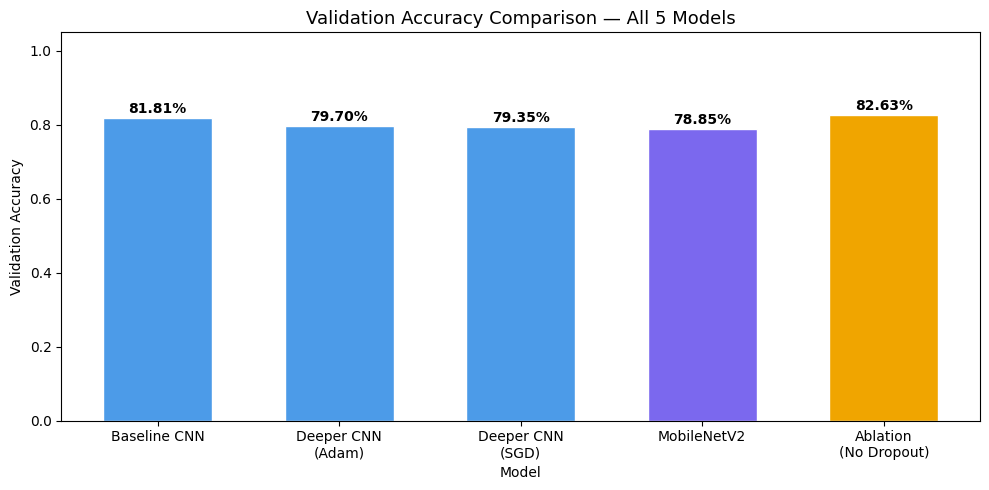


Model Summary:
--------------------------------------------------
Baseline CNN                    0.8181
Deeper CNN (Adam)               0.7970
Deeper CNN (SGD)                0.7935
MobileNetV2                     0.7885
Ablation (No Dropout)           0.8263


In [32]:
import matplotlib.pyplot as plt
import numpy as np

model_names  = ['Baseline CNN', 'Deeper CNN\n(Adam)', 'Deeper CNN\n(SGD)', 'MobileNetV2', 'Ablation\n(No Dropout)']
accuracies   = [baseline_acc,   deeper_acc,           sgd_acc,            transfer_acc,  ablation_acc]

colors = ['#4C9BE8', '#4C9BE8', '#4C9BE8', '#7B68EE', '#F0A500']

plt.figure(figsize=(10, 5))
bars = plt.bar(model_names, accuracies, color=colors, edgecolor='white', width=0.6)

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.005,
             f'{acc:.2%}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.title('Validation Accuracy Comparison — All 5 Models', fontsize=13)
plt.xlabel('Model')
plt.ylabel('Validation Accuracy')
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

print('\nModel Summary:')
print('-' * 50)
for name, acc in zip(model_names, accuracies):
    print(f'{name.replace(chr(10), " "):30s}  {acc:.4f}')
